In [48]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px
from scipy import stats
from scipy.stats import skew
from statsmodels.stats.multitest import multipletests



pd.set_option('display.float_format', '{:.2f}'.format)

In [49]:
wine = fetch_ucirepo(id=186)

In [50]:
# wine

In [51]:
# type(wine)
# # 


In [52]:
wine_df = pd.DataFrame.from_dict(wine.data.original)

wine_df.to_csv('Wine.csv')

wine_df.head(5)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,red
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5,red
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5,red
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6,red
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,red


In [53]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [54]:
(wine_df_summary := wine_df.describe())

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.07,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00


### Inspect Wine dataframe based on Wine color

In [55]:
print(f'The \'color\' column of the wine dataframe contains {len(wine_colors:=list(wine_df['color'].unique()))} colors : {wine_colors}')

The 'color' column of the wine dataframe contains 2 colors : ['red', 'white']


#### Inspection of the Red wine collection

In [56]:
red_wine_df = wine_df.query("color=='red'")

display(red_wine_df.head())

print(f'Red wine dataframe has the shape {red_wine_df.shape}')

print(f'''   
Empty Values ?
 The Red wine collection has {sum(red_wine_df.isna().sum())} missing values \n
Duplicate Values ? \n
    Total Duplicates:
      The Red wine collection has \'{(num_dup := red_wine_df.duplicated().sum())}\' duplicate values out of \'{(total_obs := red_wine_df. shape[0])}\' observations
      
    Distinct Duplicate Pattern:
      Exactly {((red_wine_duplicated := red_wine_df[red_wine_df.duplicated].value_counts().to_frame()['count'].apply(lambda x: x + 1)) > 1).sum()} distinct rows appear more than once in the Red wine collection
  
The most occuring entry appears {max(red_wine_duplicated)} times
      ''')

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,red
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5,red
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5,red
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6,red
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,red


Red wine dataframe has the shape (1599, 13)
   
Empty Values ?
 The Red wine collection has 0 missing values 

Duplicate Values ? 

    Total Duplicates:
      The Red wine collection has '240' duplicate values out of '1599' observations

    Distinct Duplicate Pattern:
      Exactly 220 distinct rows appear more than once in the Red wine collection

The most occuring entry appears 4 times
      


#### Inspection of the White wine collection 

In [57]:
white_wine_df = wine_df.query("color=='white'")

display(white_wine_df.head())

print(f'White wine dataframe has the shape {white_wine_df.shape}')

print(f'''   
Empty Values ?
 The White wine collection has {sum(white_wine_df.isna().sum())} missing values \n
Duplicate Values ? \n
    Total Duplicates:
      The White wine collection has \'{(num_dup := white_wine_df.duplicated().sum())}\' duplicate values out of \'{(total_obs := white_wine_df. shape[0])}\' observations
      
    Distinct Duplicate Pattern:
      Exactly {((white_wine_duplicated := white_wine_df[white_wine_df.duplicated].value_counts().to_frame()['count'].apply(lambda x: x + 1)) > 1).sum()} distinct rows appear more than once in the white wine collection
  
The most occuring entry appears {max(white_wine_duplicated)} times
      ''')

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
1599,7.00,0.27,0.36,20.70,0.04,45.00,170.00,1.00,3.00,0.45,8.80,6,white
1600,6.30,0.30,0.34,1.60,0.05,14.00,132.00,0.99,3.30,0.49,9.50,6,white
1601,8.10,0.28,0.40,6.90,0.05,30.00,97.00,1.00,3.26,0.44,10.10,6,white
1602,7.20,0.23,0.32,8.50,0.06,47.00,186.00,1.00,3.19,0.40,9.90,6,white
1603,7.20,0.23,0.32,8.50,0.06,47.00,186.00,1.00,3.19,0.40,9.90,6,white


White wine dataframe has the shape (4898, 13)
   
Empty Values ?
 The White wine collection has 0 missing values 

Duplicate Values ? 

    Total Duplicates:
      The White wine collection has '937' duplicate values out of '4898' observations

    Distinct Duplicate Pattern:
      Exactly 772 distinct rows appear more than once in the white wine collection

The most occuring entry appears 8 times
      


### Wine Dataframe statistical exploration

In [58]:
diff = wine_df_summary.loc['max'] - wine_df_summary.loc['75%']
condition = diff > wine_df_summary.loc['mean']
sus_columns = wine_df_summary.columns[condition].tolist()

sus_columns

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'sulphates']

In [59]:
# for item, value in dict(wine_df_summary.loc['max']).items():
#     for item, upper_limit in dict(wine_df_summary.loc['75%']).items():
#         for item, mean_value in dict(wine_df_summary.loc['mean']).items():
#             if (value - upper_limit > mean_value):
#                 sus_columns.append(item)

In [60]:
# Q3 = wine_df_summary.loc['75%', 'residual_sugar']
# Q1 = wine_df_summary.loc['25%', 'residual_sugar']

# IQR = Q3 - Q1


# print(f'Upper Limit: { Q3 + (1.5 * IQR)} \nLower Limit: { Q1 - (1.5 * IQR)}')


In [61]:
for col in wine_df_summary.columns:
    Q1 = wine_df_summary.loc['25%', col]
    Q3 = wine_df_summary.loc['75%', col]
    
    IQR = Q3 - Q1
    
    wine_df_summary.loc['lower_fence', col] = Q1 - (1.5 * IQR)
    wine_df_summary.loc['upper_fence', col] = Q3 + (1.5 * IQR)
    
    bounded_obs = ~ (
        
        wine_df[col].between(
            
            wine_df_summary.loc['lower_fence', col], 
            wine_df_summary.loc['upper_fence', col]
            
            )
                     )
    
    wine_df_summary.loc['outliers', col] = bounded_obs.sum()
    
    

In [62]:
wine_df_summary

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.07,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00
lower_fence,4.45,-0.02,0.04,-7.65,-0.00,-19.00,-41.50,0.99,2.79,0.17,6.80,3.50
upper_fence,9.65,0.66,0.60,17.55,0.11,77.00,274.50,1.00,3.63,0.85,14.00,7.50


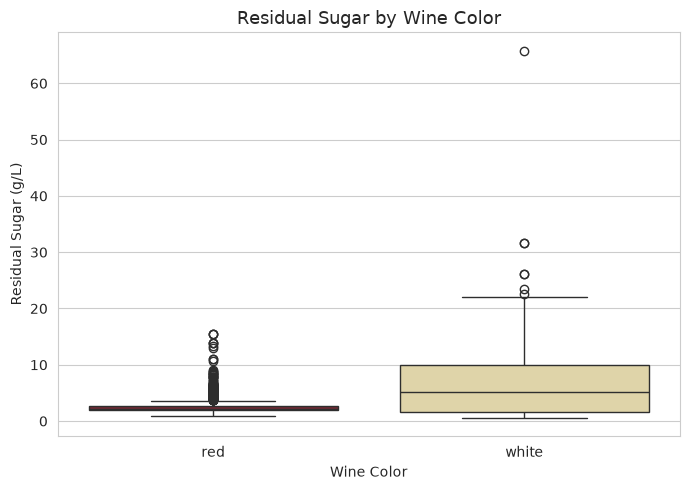

In [63]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=wine_df,
    x='color',
    y='residual_sugar',
    hue='color',
    palette={'red': '#7b1e2b', 'white': '#e8d9a0'},
    legend=False,
    ax=ax
)

ax.set_title('Residual Sugar by Wine Color', fontsize=13)
ax.set_xlabel('Wine Color')
ax.set_ylabel('Residual Sugar (g/L)')

plt.tight_layout()

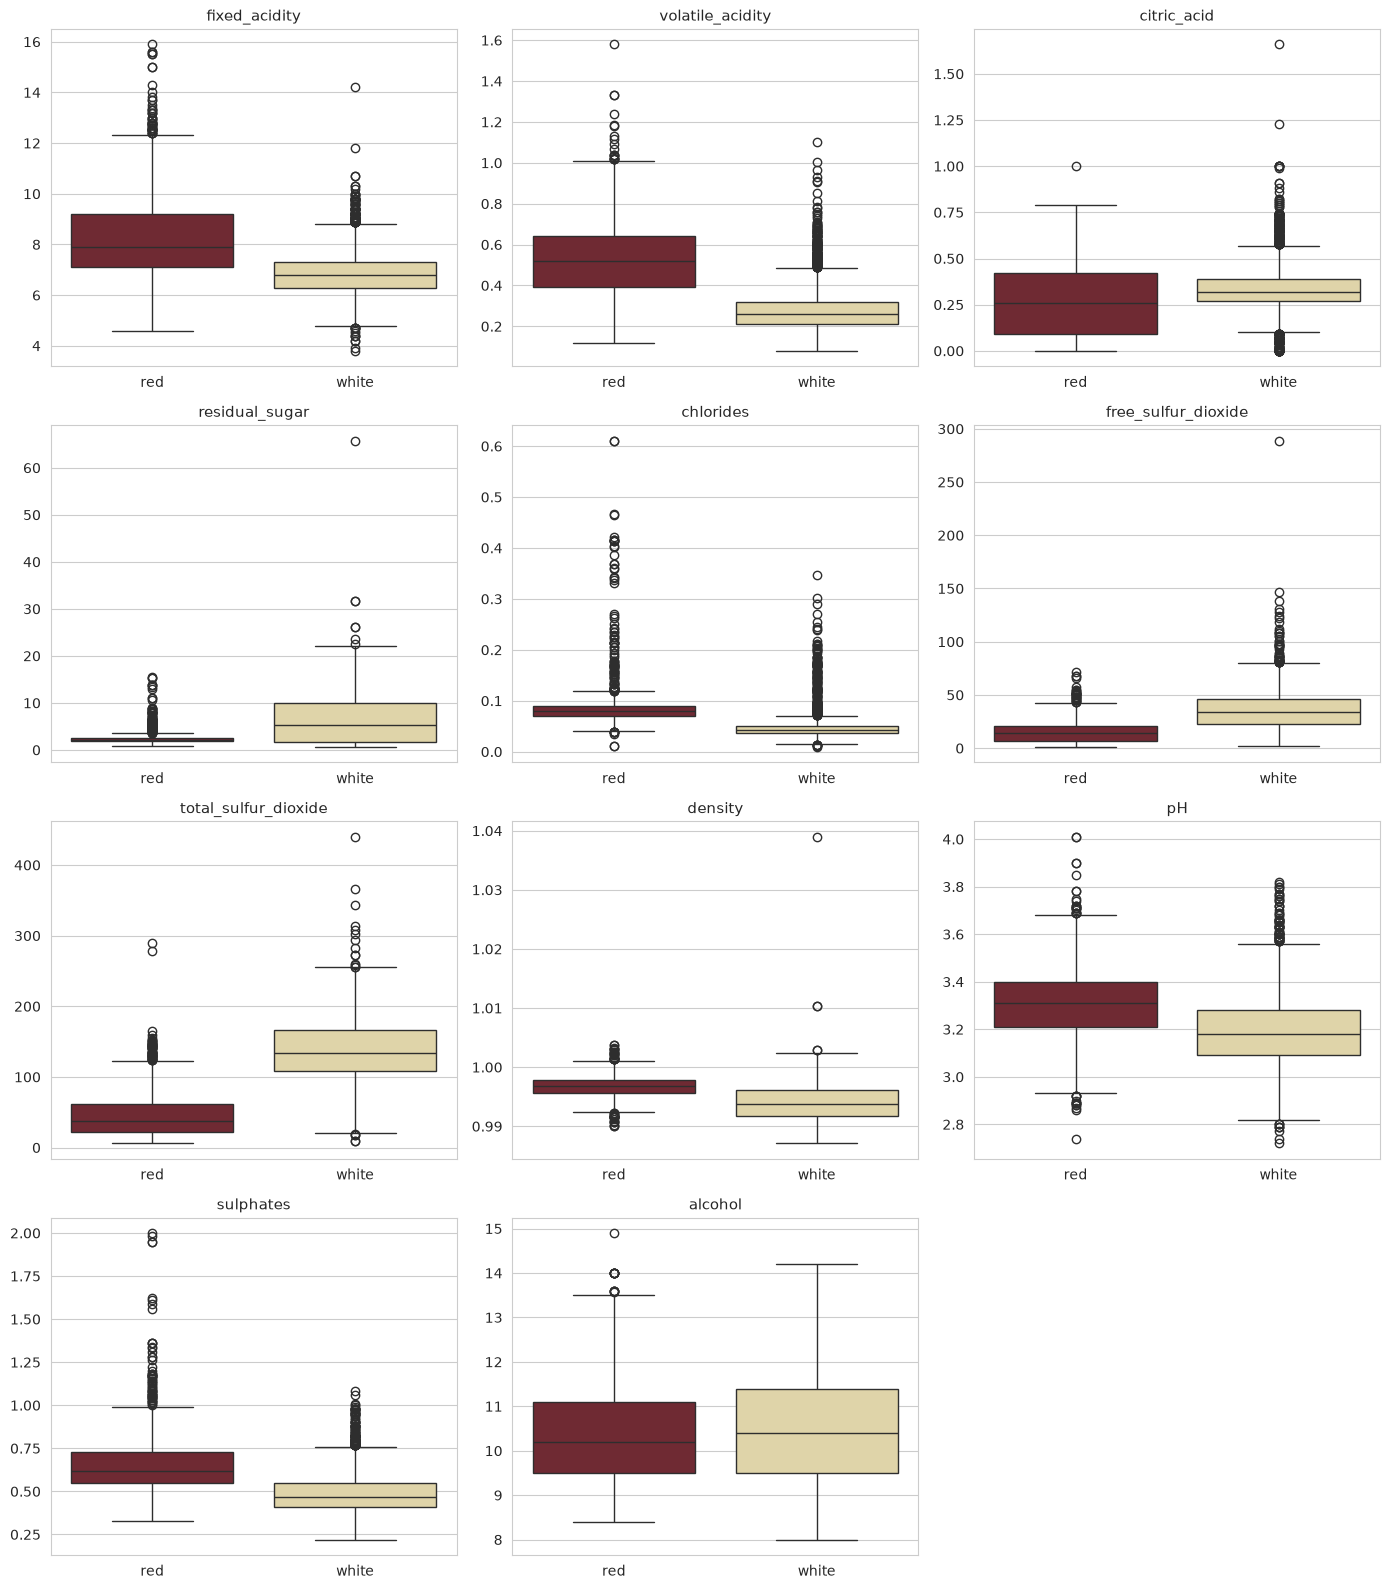

In [74]:
physicochemical_vars = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
    'density', 'pH', 'sulphates', 'alcohol'
]

sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.flatten()

palette = {'red': '#7b1e2b', 'white': '#e8d9a0'}

for i, col in enumerate(physicochemical_vars):
    sns.boxplot(
        data=wine_df, x='color', y=col, hue='color',
        palette=palette, legend=False, ax=axes[i]
    )
    
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# hide the unused 12th subplot slot
axes[-1].axis('off')

plt.tight_layout()

In [65]:
def summarize(group_df, group_name):
    rows = []
    for col in physicochemical_vars:
        s = group_df[col]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        rows.append({
            'variable': col,
            'mean': s.mean(),
            'median': s.median(),
            'variance': s.var(),
            'std': s.std(),
            'IQR': q3 - q1,
            'range': s.max() - s.min(),
            'skewness': skew(s),
            'CV_%': (s.std() / s.mean()) * 100
        })
    out = pd.DataFrame(rows).set_index('variable')
    out.columns = pd.MultiIndex.from_product([[group_name], out.columns])
    return out

red_summary = summarize(wine_df[wine_df['color'] == 'red'], 'Red')
white_summary = summarize(wine_df[wine_df['color'] == 'white'], 'White')

display(red_summary)

combined = pd.concat([red_summary, white_summary], axis=1)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
print(combined)

combined.to_csv('descriptive_stats_by_color.csv')

Red                                                  
                      mean median variance   std   IQR  range skewness  CV_%
variable                                                                    
fixed_acidity         8.32   7.90     3.03  1.74  2.10  11.30     0.98 20.93
volatile_acidity      0.53   0.52     0.03  0.18  0.25   1.46     0.67 33.92
citric_acid           0.27   0.26     0.04  0.19  0.33   1.00     0.32 71.89
residual_sugar        2.54   2.20     1.99  1.41  0.70  14.60     4.54 55.54
chlorides             0.09   0.08     0.00  0.05  0.02   0.60     5.68 53.81
free_sulfur_dioxide  15.87  14.00   109.41 10.46 14.00  71.00     1.25 65.89
total_sulfur_dioxide 46.47  38.00  1082.10 32.90 40.00 283.00     1.51 70.79
density               1.00   1.00     0.00  0.00  0.00   0.01     0.07  0.19
pH                    3.31   3.31     0.02  0.15  0.19   1.27     0.19  4.66
sulphates             0.66   0.62     0.03  0.17  0.18   1.67     2.43 25.76
alcohol              10.42  10.20     1.14  1.07  1.60   6.50     0.86 10.22

                        Red                                                         White                                                       
                       mean median variance    std    IQR   range skewness   CV_%    mean  median variance    std    IQR   range skewness   CV_%
variable                                                                                                                                        
fixed_acidity         8.320  7.900    3.031  1.741  2.100  11.300    0.982 20.928   6.855   6.800    0.712  0.844  1.000  10.400    0.648 12.311
volatile_acidity      0.528  0.520    0.032  0.179  0.250   1.460    0.671 33.924   0.278   0.260    0.010  0.101  0.110   1.020    1.576 36.226
citric_acid           0.271  0.260    0.038  0.195  0.330   1.000    0.318 71.889   0.334   0.320    0.015  0.121  0.120   1.660    1.282 36.213
residual_sugar        2.539  2.200    1.988  1.410  0.700  14.600    4.536 55.535   6.391   5.200   25.726  5.072  8.200  65.200  

#### Statistical Comparison

##### Check if the variables are qualified enough for t-test
Using :
- Shapiro-Wilk's test to check the categories against normality (this test is very sensitive) [The null hypothesis assujmes that the categories are normal]
- Student's Independence Test to check for equal variance of the variables
- 

In [66]:
results = []

for col in physicochemical_vars:
    r = red_wine_df[col].values
    w = white_wine_df[col].values

    # Shapiro-Wilk: subsample if n > 5000 (scipy caps meaningfully there anyway)
    # White has 4898, under the cap, so we can run directly, but let's be consistent
    sw_red_stat, sw_red_p = stats.shapiro(r)
    sw_white_stat, sw_white_p = stats.shapiro(w)

    # Levene's test for equal variances
    lev_stat, lev_p = stats.levene(r, w)

    normal_red = sw_red_p > 0.05
    normal_white = sw_white_p > 0.05
    equal_var = lev_p > 0.05

    if normal_red and normal_white:
        if equal_var:
            test_used = "Student's t-test"
            stat, p = stats.ttest_ind(r, w, equal_var=True)
        else:
            test_used = "Welch's t-test"
            stat, p = stats.ttest_ind(r, w, equal_var=False)
    else:
        test_used = "Mann-Whitney U"
        stat, p = stats.mannwhitneyu(r, w, alternative='two-sided')

    results.append({
        'variable': col,
        'shapiro_p_red': sw_red_p,
        'shapiro_p_white': sw_white_p,
        'levene_p': lev_p,
        'normal_red': normal_red,
        'normal_white': normal_white,
        'equal_var': equal_var,
        'test_used': test_used,
        'test_stat': stat,
        'p_value': p
    })

results_df = pd.DataFrame(results).set_index('variable')
pd.set_option('display.max_columns', None)
# pd.set_option('display.width', 0)
pd.set_option('display.float_format', lambda x: f'{x:.4g}')

results_df.to_csv('test_selection_results.csv')

results_df

,shapiro_p_red,shapiro_p_white,levene_p,normal_red,normal_white,equal_var,test_used,test_stat,p_value
variable,,,,,,,,,
fixed_acidity,1.525e-24,1.15e-27,2.333e-193,False,False,False,Mann-Whitney U,6.139e+06,1.439e-255
volatile_acidity,2.693e-16,4.587e-48,4.42e-176,False,False,False,Mann-Whitney U,7.06e+06,0
citric_acid,1.022e-21,1.013e-44,3.215e-184,False,False,False,Mann-Whitney U,3.07e+06,1.313e-38
residual_sugar,1.02e-52,2.821e-51,0,False,False,False,Mann-Whitney U,2.57e+06,5.634e-95
chlorides,1.179e-55,2.141e-75,1.549e-28,False,False,False,Mann-Whitney U,7.407e+06,0
free_sulfur_dioxide,7.695e-31,3.858e-40,1.339e-66,False,False,False,Mann-Whitney U,1.186e+06,0
total_sulfur_dioxide,3.573e-34,4.383e-19,8.507e-41,False,False,False,Mann-Whitney U,3.666e+05,0
density,1.936e-08,1.781e-36,8.505e-97,False,False,False,Mann-Whitney U,6.059e+06,1.453e-237
pH,1.712e-06,6.506e-20,0.4877,False,False,True,Mann-Whitney U,5.682e+06,5.472e-162


##### Correcting for the oversensitivity of the Shapiro Wilk test before locking in on Mann Whitney U's test

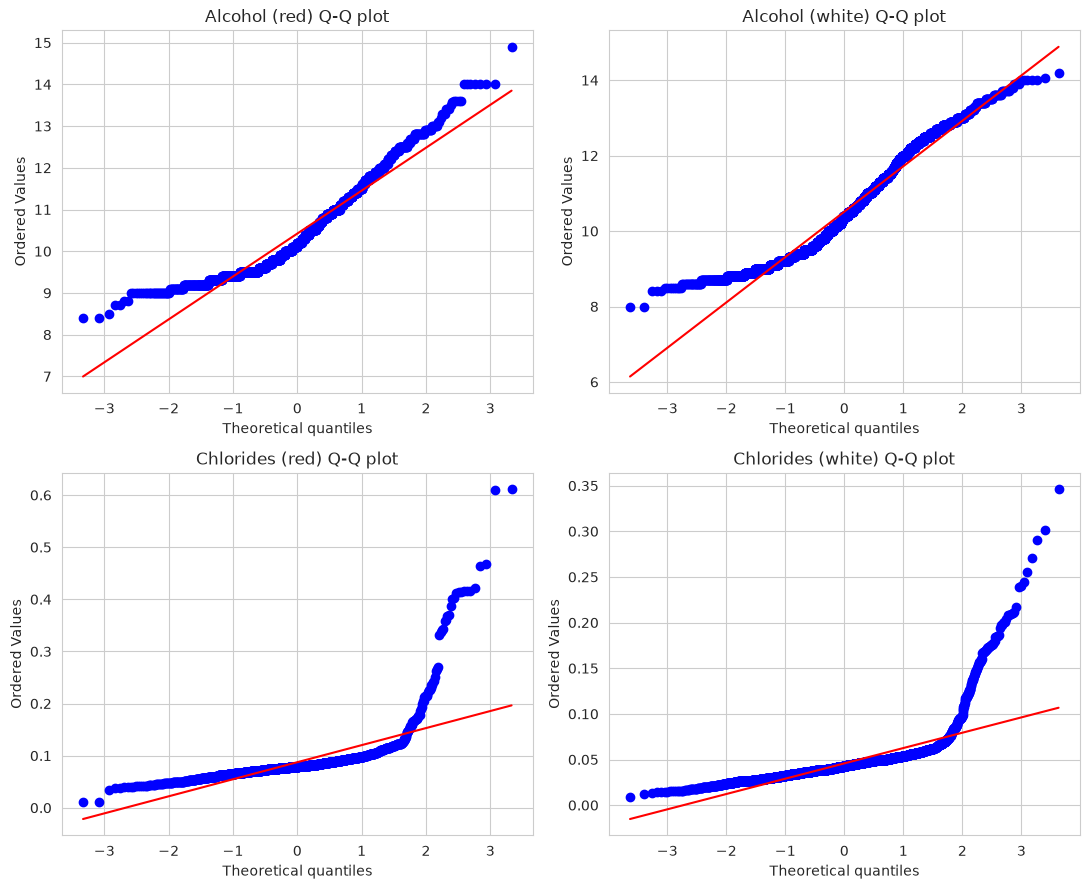

In [67]:
red = wine_df[wine_df['color'] == 'red']
white = wine_df[wine_df['color'] == 'white']

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# Alcohol - red and white
stats.probplot(red['alcohol'], dist="norm", plot=axes[0,0])
axes[0,0].set_title('Alcohol (red) Q-Q plot')

stats.probplot(white['alcohol'], dist="norm", plot=axes[0,1])
axes[0,1].set_title('Alcohol (white) Q-Q plot')

# Chlorides - red and white
stats.probplot(red['chlorides'], dist="norm", plot=axes[1,0])
axes[1,0].set_title('Chlorides (red) Q-Q plot')

stats.probplot(white['chlorides'], dist="norm", plot=axes[1,1])
axes[1,1].set_title('Chlorides (white) Q-Q plot')

plt.tight_layout()
plt.savefig('charts/qq_comparison.png', dpi=150)

##### Separate "statistically detectable" from "actually substantial,"

- The power of `Effect Size`

In [68]:
n1, n2 = len(red), len(white)
results = []

for col in physicochemical_vars:
    r_vals = red[col].values
    w_vals = white[col].values

    U, p = stats.mannwhitneyu(r_vals, w_vals, alternative='two-sided')

    # rank-biserial correlation (from U statistic, relative to red as group 1)
    rank_biserial = 1 - (2 * U) / (n1 * n2)

    # common language effect size: P(red > white) for a random pair
    # U / (n1*n2) gives P(group1 > group2) directly from Mann-Whitney U definition
    cles = U / (n1 * n2)

    results.append({
        'variable': col,
        'p_value': p,
        'rank_biserial_r': rank_biserial,
        'CLES_P(red>white)': cles,
        'abs_r': abs(rank_biserial)
    })

results_df = pd.DataFrame(results).set_index('variable')
results_df = results_df.sort_values('abs_r', ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(results_df.drop(columns='abs_r'))

results_df.to_csv('data/effect_sizes.csv')

                      p_value  rank_biserial_r  CLES_P(red>white)
variable                                                         
total_sulfur_dioxide   0.0000           0.9064             0.0468
chlorides              0.0000          -0.8915             0.9457
volatile_acidity       0.0000          -0.8028             0.9014
free_sulfur_dioxide    0.0000           0.6970             0.1515
sulphates              0.0000          -0.6624             0.8312
fixed_acidity          0.0000          -0.5676             0.7838
density                0.0000          -0.5473             0.7737
pH                     0.0000          -0.4509             0.7255
residual_sugar         0.0000           0.3438             0.3281
citric_acid            0.0000           0.2160             0.3920
alcohol                0.1818           0.0222             0.4889


##### Confidence Interval 

Bootstrap Resampling

In [69]:
np.random.seed(42)
n_boot = 10000

vars_to_check = ['total_sulfur_dioxide', 'residual_sugar', 'alcohol', 'chlorides']

results = []

for col in vars_to_check:
    r_vals = red[col].values
    w_vals = white[col].values

    observed_diff = r_vals.mean() - w_vals.mean()

    boot_diffs = np.empty(n_boot)
    for i in range(n_boot):
        r_sample = np.random.choice(r_vals, size=len(r_vals), replace=True)
        w_sample = np.random.choice(w_vals, size=len(w_vals), replace=True)
        boot_diffs[i] = r_sample.mean() - w_sample.mean()

    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)

    results.append({
        'variable': col,
        'observed_mean_diff (red - white)': observed_diff,
        'CI_lower_2.5%': ci_lower,
        'CI_upper_97.5%': ci_upper,
        'CI_excludes_zero': not (ci_lower <= 0 <= ci_upper)
    })

results_df = pd.DataFrame(results).set_index('variable')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
results_df

,observed_mean_diff (red - white),CI_lower_2.5%,CI_upper_97.5%,CI_excludes_zero
variable,,,,
total_sulfur_dioxide,-91.8929,-93.8927,-89.8682,True
residual_sugar,-3.8526,-4.0139,-3.6999,True
alcohol,-0.0913,-0.1548,-0.0263,True
chlorides,0.0417,0.0394,0.0441,True


##### Correlation Analysis

In [70]:
def corr_table(group_df, group_name):
    rows = []
    for col in physicochemical_vars:
        pearson_r, pearson_p = stats.pearsonr(group_df[col], group_df['quality'])
        spearman_r, spearman_p = stats.spearmanr(group_df[col], group_df['quality'])
        rows.append({
            'variable': col,
            'pearson_r': pearson_r,
            'pearson_p': pearson_p,
            'spearman_r': spearman_r,
            'spearman_p': spearman_p,
            'abs_diff': abs(pearson_r - spearman_r)
        })
    out = pd.DataFrame(rows).set_index('variable')
    out = out.sort_values('spearman_r', key=abs, ascending=False)
    return out

red_corr = corr_table(red, 'red')
white_corr = corr_table(white, 'white')

print("=== RED: correlation with quality ===")
print(red_corr)
print()
print("=== WHITE: correlation with quality ===")
print(white_corr)

red_corr.to_csv('data/red_quality_corr.csv')
white_corr.to_csv('data/white_quality_corr.csv')

=== RED: correlation with quality ===
                      pearson_r  pearson_p  spearman_r  spearman_p  abs_diff
variable                                                                    
alcohol                  0.4762     0.0000      0.4785      0.0000    0.0024
volatile_acidity        -0.3906     0.0000     -0.3806      0.0000    0.0099
sulphates                0.2514     0.0000      0.3771      0.0000    0.1257
citric_acid              0.2264     0.0000      0.2135      0.0000    0.0129
total_sulfur_dioxide    -0.1851     0.0000     -0.1967      0.0000    0.0116
chlorides               -0.1289     0.0000     -0.1899      0.0000    0.0610
density                 -0.1749     0.0000     -0.1771      0.0000    0.0022
fixed_acidity            0.1241     0.0000      0.1141      0.0000    0.0100
free_sulfur_dioxide     -0.0507     0.0428     -0.0569      0.0229    0.0062
pH                      -0.0577     0.0210     -0.0437      0.0808    0.0141
residual_sugar           0.0137     0.

Correlation maps

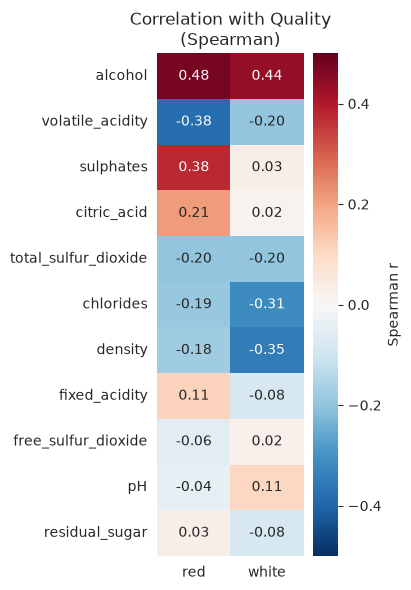

In [71]:
# --- Heatmap 1: variable vs quality, red & white side by side ---
red_q_corr = red[physicochemical_vars + ['quality']].corr(method='spearman')['quality'].drop('quality')
white_q_corr = white[physicochemical_vars + ['quality']].corr(method='spearman')['quality'].drop('quality')

quality_corr_df = pd.DataFrame({'red': red_q_corr, 'white': white_q_corr})
quality_corr_df = quality_corr_df.reindex(quality_corr_df['red'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(4, 6))
sns.heatmap(quality_corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, ax=ax, cbar_kws={'label': 'Spearman r'})
ax.set_title('Correlation with Quality\n(Spearman)', fontsize=12)
plt.tight_layout()
plt.savefig('charts/quality_corr_heatmap.png', dpi=150)
plt.show()

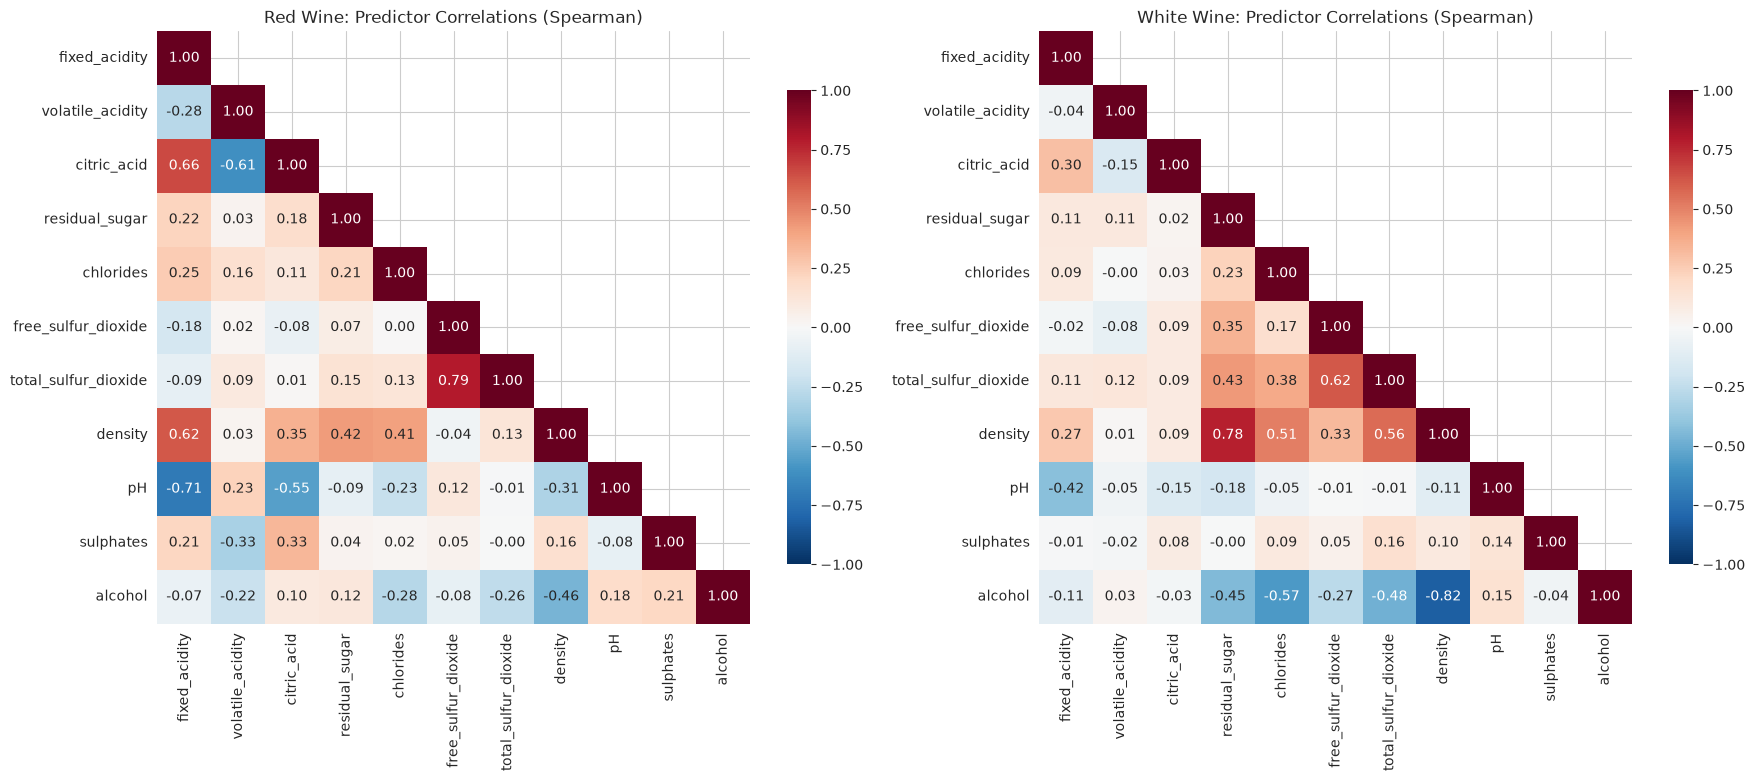

In [72]:
# --- Heatmap 2: full predictor-predictor matrices, red and white ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

red_full_corr = red[physicochemical_vars].corr(method='spearman')
white_full_corr = white[physicochemical_vars].corr(method='spearman')

mask_red = np.triu(np.ones_like(red_full_corr, dtype=bool), k=1)
mask_white = np.triu(np.ones_like(white_full_corr, dtype=bool), k=1)

sns.heatmap(red_full_corr, mask=mask_red, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0], square=True, cbar_kws={'shrink': 0.7})
axes[0].set_title('Red Wine: Predictor Correlations (Spearman)', fontsize=12)

sns.heatmap(white_full_corr, mask=mask_white, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[1], square=True, cbar_kws={'shrink': 0.7})
axes[1].set_title('White Wine: Predictor Correlations (Spearman)', fontsize=12)

plt.tight_layout()
plt.savefig('charts/predictor_corr_heatmaps.png', dpi=150)
plt.show()

In [73]:
all_tests = []

# Phase 5 tests: Mann-Whitney red vs white, per variable (11 tests)
for col in physicochemical_vars:
    U, p = stats.mannwhitneyu(red[col], white[col], alternative='two-sided')
    all_tests.append({'test_family': 'red_vs_white_MWU', 'variable': col, 'p_value': p})

# Phase 6 tests: Pearson and Spearman vs quality, per variable, per color (44 tests)
for group_name, group_df in [('red', red), ('white', white)]:
    for col in physicochemical_vars:
        _, p_pearson = stats.pearsonr(group_df[col], group_df['quality'])
        _, p_spearman = stats.spearmanr(group_df[col], group_df['quality'])
        all_tests.append({'test_family': f'{group_name}_pearson_quality', 'variable': col, 'p_value': p_pearson})
        all_tests.append({'test_family': f'{group_name}_spearman_quality', 'variable': col, 'p_value': p_spearman})

results_df = pd.DataFrame(all_tests)
m = len(results_df)
print(f"Total tests conducted: {m}")

# Bonferroni
bonf_reject, bonf_adj_p, _, _ = multipletests(results_df['p_value'], alpha=0.05, method='bonferroni')
results_df['bonferroni_adj_p'] = bonf_adj_p
results_df['bonferroni_reject'] = bonf_reject

# Benjamini-Hochberg FDR
fdr_reject, fdr_adj_p, _, _ = multipletests(results_df['p_value'], alpha=0.05, method='fdr_bh')
results_df['fdr_adj_p'] = fdr_adj_p
results_df['fdr_reject'] = fdr_reject

# raw significance for comparison
results_df['raw_reject'] = results_df['p_value'] < 0.05

print(f"\nRaw significant (p<0.05):      {results_df['raw_reject'].sum()} / {m}")
print(f"Bonferroni significant:        {results_df['bonferroni_reject'].sum()} / {m}")
print(f"FDR (BH) significant:          {results_df['fdr_reject'].sum()} / {m}")

# show any that were raw-significant but fail after correction
flipped = results_df[results_df['raw_reject'] & (~results_df['bonferroni_reject'] | ~results_df['fdr_reject'])]
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.float_format', lambda x: f'{x:.5f}')
print("\n=== Tests that were 'significant' raw but flip after correction ===")
print(flipped[['test_family', 'variable', 'p_value', 'bonferroni_adj_p', 'bonferroni_reject', 'fdr_adj_p', 'fdr_reject']].to_string())

results_df.to_csv('data/multiple_comparisons_results.csv', index=False)

Total tests conducted: 55

Raw significant (p<0.05):      47 / 55
Bonferroni significant:        43 / 55
FDR (BH) significant:          46 / 55

=== Tests that were 'significant' raw but flip after correction ===
               test_family             variable  p_value  bonferroni_adj_p  bonferroni_reject  fdr_adj_p  fdr_reject
21     red_pearson_quality  free_sulfur_dioxide  0.04283           1.00000              False    0.05012       False
22    red_spearman_quality  free_sulfur_dioxide  0.02288           1.00000              False    0.02736        True
27     red_pearson_quality                   pH  0.02096           1.00000              False    0.02562        True
52  white_spearman_quality            sulphates  0.01971           1.00000              False    0.02463        True
